# 01 — Preprocessing Validation

Confirms the signal pipeline produces plausible output on real PhysioNet EEGBCI data.

**Gate:** `epoch_count > 0`, `latest()` returns shape `(64, 160)`, PSD shows energy concentrated in the 8–30 Hz band.

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from src.preprocessing.pipeline import load_and_epoch_subject
from src.preprocessing.buffer import EpochBuffer
from src.preprocessing.streaming import PlaybackThread, PipelineThread
import queue, time

In [2]:
X, y = load_and_epoch_subject(subject=1)
print(f"Epochs: {X.shape}, Labels: {np.bincount(y)}")
# Expected: (n_epochs, 64, 160), 3 non-zero label counts

Epochs: (77, 64, 160), Labels: [35 20 22]


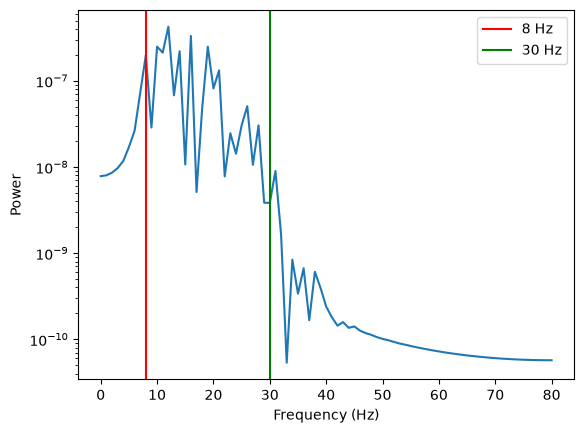

In [3]:
fig, ax = plt.subplots()
freqs = np.fft.rfftfreq(160, d=1/160)
psd = np.abs(np.fft.rfft(X[0].mean(axis=0))) ** 2
ax.semilogy(freqs, psd)
ax.axvline(8, color='r', label='8 Hz')
ax.axvline(30, color='g', label='30 Hz')
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power")
ax.legend()
plt.show()
# Should see energy concentrated between 8-30 Hz, near-zero outside

In [4]:
raw_fnames = mne.datasets.eegbci.load_data(1, [4])
raw = mne.io.read_raw_edf(raw_fnames[0], preload=True, verbose=False)
data = raw.get_data()
sfreq = raw.info['sfreq']

sample_q = queue.Queue(maxsize=5000)
epoch_buf = EpochBuffer()

playback = PlaybackThread(data, sfreq, sample_q)
pipeline = PipelineThread(sample_q, epoch_buf, sfreq=sfreq)
playback.start()
pipeline.start()
time.sleep(3.0)
playback.stop()
pipeline.stop()

stats = epoch_buf.stats()
print(f"Buffer stats: {stats}")
print(f"Latest epoch shape: {epoch_buf.latest().shape}")
# Expected: epoch_count > 0, snr > 0, latest = (64, 160)

Buffer stats: {'snr': 6.501183065303111, 'artifact_ratio': 0.0, 'epoch_count': 6}
Latest epoch shape: (64, 160)
